In [1]:
import numpy as np
import pandas as pd

# Create a random number generator with a seed
rng = np.random.default_rng(seed=42)

# Import data
URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(URL)

Add a new col
`df['new_col_name'] = new_column_values`

or

`df = df.assign(new_col_name=new_column_values)`

At a specific location
`df.insert(loc=integer_index,  # Location of new column
          column='new_col_name', 
          value=new_col_values)`

Add mulitple columns
`df = df.assign(new_col1_name=new_col1_values, 
               new_col2_name=new_col2_values)`

Add a new key-value pair to a dictioary
`dict[new_key] = new_value`

In [2]:
# Add new column body_mass_kg 
penguins['body_mass_kg'] = penguins['body_mass_g']/1000

# Confirm the new column is in the data frame
print("body_mass_kg is in the data frame's columns: ", 'body_mass_kg' in penguins.columns)

# Look at the new column
penguins.head()

body_mass_kg is in the data frame's columns:  True


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,body_mass_kg
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,3.75
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,3.80
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,3.25
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,3.45


<Axes: xlabel='bill_length_cm', ylabel='body_mass_g'>

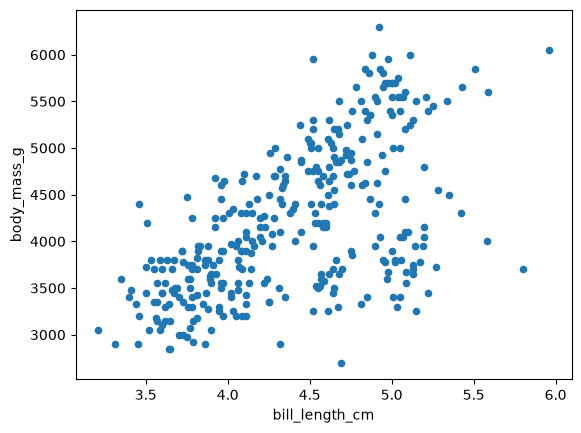

In [3]:
(penguins.assign(bill_length_cm=penguins['bill_length_mm']/10)
        .plot(kind='scatter',
              x='bill_length_cm', 
              y='body_mass_g')
    )

In [4]:
# Create random 3-digit codes
codes = rng.choice(np.arange(100, 1000), size=len(penguins), replace=False)  # Sampling w/o replacement

# Insert codes at the front of data frame
penguins.insert(loc=0,  # First position
                column='id_code',
                value=codes)
        
penguins.head()

,id_code,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,body_mass_kg
0,630,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,3.75
1,679,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,3.80
2,175,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,3.25
3,330,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007,NaN
4,355,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,3.45


In [5]:
# Create columns with observer codes and flipper length in cm
penguins = penguins.assign(flipper_length_cm=penguins['flipper_length_mm']/10, 
                           observer=rng.choice(['A','B','C'],  # Sample with replacement
                            size=len(penguins))
                          )
# Examine result
penguins.head()

,id_code,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,body_mass_kg,flipper_length_cm,observer
0,630,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,3.75,18.1,B
1,679,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,3.80,18.6,B
2,175,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,3.25,19.5,C
3,330,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007,NaN,NaN,C
4,355,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,3.45,19.3,C


Removing columns
`df = df.drop(columns=col_names)`

In [6]:
# Remove duplicate length and mass measurements
penguins = penguins.drop(columns=['flipper_length_mm','body_mass_g'])

# Confirm result
print(penguins.columns)

Index(['id_code', 'species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'sex', 'year', 'body_mass_kg', 'flipper_length_cm', 'observer'],
      dtype='str')


Update values

Single value

at[] to select by labels, or
iat[] to select by position.

`df.at[single_index_value, 'column_name']`

`df.iat[index_integer_location, column_integer_location]`

Get index 
`penguins.columns.get_loc('column_name')`

In [7]:
# Update the index of the data frame to be the id_code column
penguins = penguins.set_index('id_code')
penguins

,species,island,bill_length_mm,bill_depth_mm,sex,year,body_mass_kg,flipper_length_cm,observer
id_code,,,,,,,,,
630,Adelie,Torgersen,39.1,18.7,male,2007,3.750,18.1,B
679,Adelie,Torgersen,39.5,17.4,female,2007,3.800,18.6,B
175,Adelie,Torgersen,40.3,18.0,female,2007,3.250,19.5,C
330,Adelie,Torgersen,NaN,NaN,NaN,2007,NaN,NaN,C
355,Adelie,Torgersen,36.7,19.3,female,2007,3.450,19.3,C
...,...,...,...,...,...,...,...,...,...
560,Chinstrap,Dream,55.8,19.8,male,2009,4.000,20.7,A
975,Chinstrap,Dream,43.5,18.1,female,2009,3.400,20.2,A
995,Chinstrap,Dream,49.6,18.2,male,2009,3.775,19.3,B


In [8]:
# Check bill length of penguin with ID 330
penguins.at[330, 'bill_length_mm']

np.float64(nan)

In [9]:
# Correct bill length value of penguin with ID 330
penguins.at[330,'bill_length_mm'] = 38.3

# Confirm value was updated
penguins.loc[330]

species                 Adelie
island               Torgersen
bill_length_mm            38.3
bill_depth_mm              NaN
sex                        NaN
year                      2007
body_mass_kg               NaN
flipper_length_cm          NaN
observer                     C
Name: 330, dtype: object

In [16]:
# Get index location of col
penguins.columns.get_loc('bill_length_mm')

2

In [17]:
# Change back to NA
penguins.iat[330,2] = 'NaN'

# Confirm value was updated
penguins.iloc[330,2]

TypeError: Invalid value 'NaN' for dtype 'float64'

In [18]:
# Update multiple cols with a condition
# Create a list with the conditions
conditions = [penguins['body_mass_kg'] < 3, 
              (3 <= penguins['body_mass_kg']) & (penguins['body_mass_kg'] < 5),
              5 <= penguins['body_mass_kg']]

# Create a list with the choices
choices = ["small",
           "medium",
           "large"]

# Add the selections using np.select
penguins['size'] = np.select(conditions, 
                             choices, 
                             default=None) # Value for anything outside conditions

# Display the updated data frame to confirm the new column
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,sex,year,body_mass_kg,flipper_length_cm,observer,size
id_code,,,,,,,,,,
630,Adelie,Torgersen,39.1,18.7,male,2007,3.75,18.1,B,medium
679,Adelie,Torgersen,39.5,17.4,female,2007,3.80,18.6,B,medium
175,Adelie,Torgersen,40.3,18.0,female,2007,3.25,19.5,C,medium
330,Adelie,Torgersen,38.3,NaN,NaN,2007,NaN,NaN,C,NaN
355,Adelie,Torgersen,36.7,19.3,female,2007,3.45,19.3,C,medium


Update multiple cols by selecting values
`df.loc[row_selection, column_name] = new_values`

Using loc[] in assignment modifies the data frame directly without the need for reassignment

In [19]:
# Select rows with sex=male and simplify values in 'sex' column
penguins.loc[penguins['sex']=='male', 'sex'] = 'M'

# Check changes in 'sex' column specifically
print(penguins['sex'].unique())

<StringArray>
['M', 'female', nan]
Length: 3, dtype: str


In [20]:
# Select rows with sex=female and simplify values in 'sex' column
penguins.loc[penguins['sex']=='female', 'sex'] = 'F'

# Check changes in 'sex' column specifically
print(penguins['sex'].unique())

<StringArray>
['M', 'F', nan]
Length: 3, dtype: str


In [25]:
# Select penguins from Biscoe island
biscoe = penguins[penguins['island']=='Biscoe']

# ... Other analyses ...

# Add a column
biscoe['sample_col'] = 100  # This raises SettingWithCopyWarning
biscoe.head()

,species,island,bill_length_mm,bill_depth_mm,sex,year,body_mass_kg,flipper_length_cm,observer,size,sample_col
id_code,,,,,,,,,,,
954,Adelie,Biscoe,37.8,18.3,F,2007,3.40,17.4,B,medium,100
503,Adelie,Biscoe,37.7,18.7,M,2007,3.60,18.0,B,medium,100
567,Adelie,Biscoe,35.9,19.2,F,2007,3.80,18.9,B,medium,100
827,Adelie,Biscoe,38.2,18.1,M,2007,3.95,18.5,C,medium,100
438,Adelie,Biscoe,38.8,17.2,M,2007,3.80,18.0,B,medium,100


In [26]:
# Confirm that original data was not modified
print('sample_col' in penguins.columns)

False
